# Ridge Regression
- Implementing Ridge Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('./cleaned_property_data.csv')

In [3]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [5]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Ridge Regression Results")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Ridge Regression Results
RMSE: 0.13
R² Score: 0.9803


In [7]:
train_r2 = r2_score(y_train,model.predict(X_train))
print(f"Train R² Score: {train_r2:.4f}")

Train R² Score: 0.9829


- Using cross validations

In [15]:
from sklearn.model_selection import cross_val_score

# Ridge model
model = Ridge(alpha=1.0)

# 5-fold cross-validation for R² score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-validated R² scores:", cv_scores)
print(f"Mean R² score: {cv_scores.mean():.4f}")

Cross-validated R² scores: [0.98070983 0.98304435 0.98299689 0.98302506 0.98127984]
Mean R² score: 0.9822


## Visualizations

1. Regression Fit vs Actual

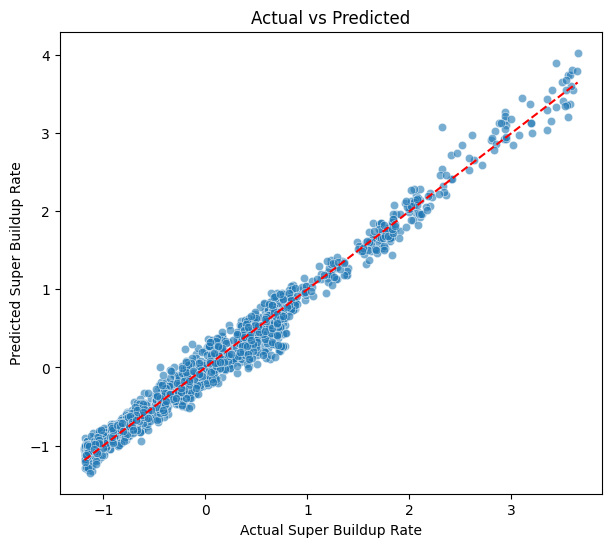

In [16]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted")
plt.show()

### 2. Residual Plot

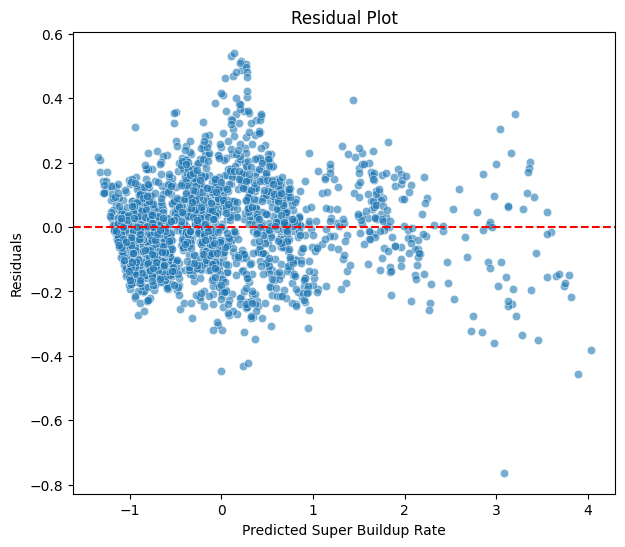

In [17]:
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Super Buildup Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### 3. Distributions of Errors

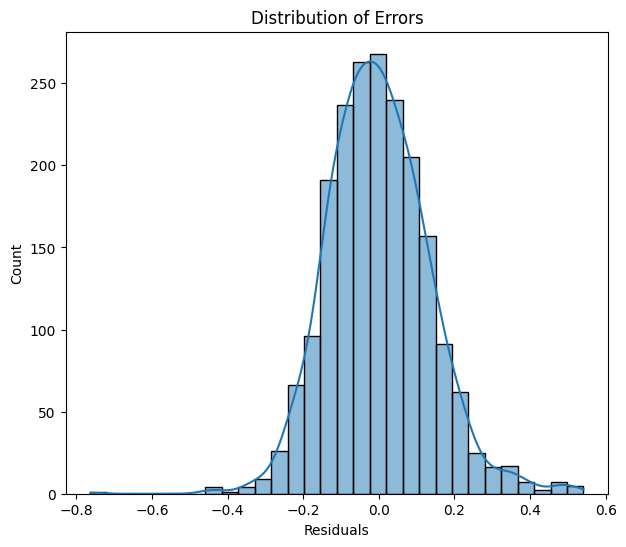

In [18]:
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residuals")
plt.title("Distribution of Errors")
plt.show()

### 4.Model performances

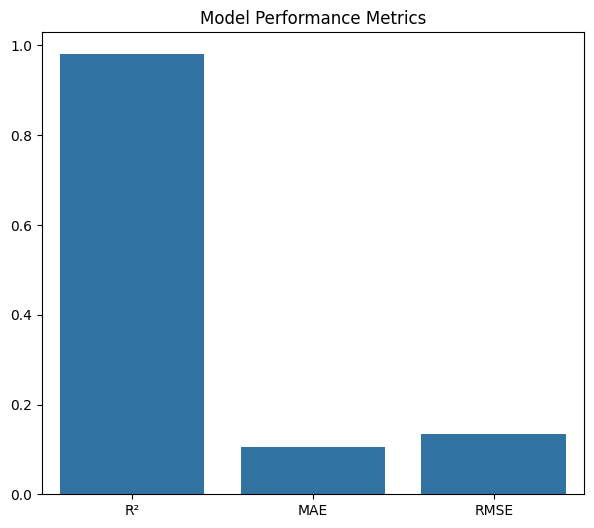

R²: 0.980, MAE: 0.104, RMSE: 0.134


In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(7,6))
sns.barplot(x=["R²", "MAE", "RMSE"], y=[r2, mae, rmse])
plt.title("Model Performance Metrics")
plt.show()

print(f"R²: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")

In [20]:
from sklearn.linear_model import RidgeCV

# Generates 50 different alpha values from 0.001(10**-3) to 1000(10**3)
alphas = np.logspace(-3, 3, 50)

# RidgeCV automatically performs cross-validation and selects the best alpha
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Best alpha: {ridge_cv.alpha_}")
print(f"Train R² Score: {ridge_cv.score(X_train, y_train):.4f}")
print(f"Test R² Score: {ridge_cv.score(X_test, y_test):.4f}")

Best alpha: 0.0517947467923121
Train R² Score: 0.9829
Test R² Score: 0.9803
